# Customer Lifetime Value Prediction

This project builds an end-to-end machine learning pipeline to predict each customer's spending over the next 90 days. It combines leakage-safe temporal feature engineering, regression modeling, customer ranking, and a GenAI extension that converts predictions into plain-English explanations.

## Dataset Overview

The analysis uses `LTV_Transactions.csv`, an e-commerce transaction dataset containing **108,728 transactions** from **500 unique customers**.

- **Time period:** July 01, 2024 to December 30, 2025
- **Columns:** `CUSTOMER_ID`, `TRANSACTION_TIME`, `AMOUNT`, `PRODUCT_CATEGORY`, and `CHANNEL`
- **Product categories:** 5
- **Purchase channels:** 3
- **Average transaction amount:** 381.34
- **Median transaction amount:** 199.46

Each row represents an individual customer transaction. The dataset is transformed from transaction-level records into customer-level behavioral features, which are then used to predict spending during a future 90-day target window.

## Project Workflow

1. Data loading and exploratory data analysis
2. Leakage-safe cutoff and target-window definition
3. Customer-level feature engineering
4. Train/test split
5. XGBoost and Random Forest regression
6. Model evaluation and feature importance
7. Customer scoring and ranking
8. GenAI-based prediction explanations
9. Production considerations and limitations


## 0. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.max_colwidth", None)  # show full GenAI explanations, not truncated

## 1. Load the Transactions Dataset (provided)

`LTV_Transactions.csv` is an 18-month e-commerce transaction log for 500 customers, about 109,000 rows. Each row is one transaction: `CUSTOMER_ID`, `TRANSACTION_TIME`, `AMOUNT`, `PRODUCT_CATEGORY`, `CHANNEL`. It was generated by an LLM-written script from a plain-language prompt, the same GenAI use case covered in the instructor slide deck.

Run the cell below as is.


In [2]:
# ---- Load Transaction Data ----
transactions = pd.read_csv("LTV_Transactions.csv", parse_dates=["TRANSACTION_TIME"])
transactions = transactions.sort_values("TRANSACTION_TIME").reset_index(drop=True)

customer_ids = sorted(transactions["CUSTOMER_ID"].unique())
START_DATE = transactions["TRANSACTION_TIME"].min()
WINDOW_DAYS = (transactions["TRANSACTION_TIME"].max() - START_DATE).days

print(f"{len(transactions):,} transactions across {transactions['CUSTOMER_ID'].nunique()} customers")
print(f"Date range: {transactions['TRANSACTION_TIME'].min().date()} to {transactions['TRANSACTION_TIME'].max().date()}")
transactions.head()

108,728 transactions across 500 customers
Date range: 2024-07-01 to 2025-12-30


,CUSTOMER_ID,TRANSACTION_TIME,AMOUNT,PRODUCT_CATEGORY,CHANNEL
0,CUST_00172,2024-07-01 00:11:42,149.99,Health & Beauty,web
1,CUST_00468,2024-07-01 00:18:23,241.56,Health & Beauty,mobile
2,CUST_00265,2024-07-01 00:19:00,106.10,Health & Beauty,mobile
3,CUST_00054,2024-07-01 00:35:54,"1,925.71",Electronics,web
4,CUST_00102,2024-07-01 00:44:09,"1,384.98",Electronics,mobile


## 2. Exploratory Data Analysis

Before building features, look for signals that predict future spend: purchase frequency, order size, recency, and category or channel preference. This data has no ground-truth "high-value" label, so you will derive one from total spend to check whether these signals actually separate big spenders from everyone else.

Build:
1. Summary statistics for `AMOUNT`
2. Three plots: amount distribution, transactions by category, transactions by channel
3. A histogram of transactions per customer
4. A table comparing high-value and regular customers on average spend and transaction count


In [3]:
# ---- Summary Statistics ----
transactions[["AMOUNT"]].describe()

,AMOUNT
count,"108,728.00"
mean,381.34
std,443.34
min,10.00
25%,109.94
50%,199.46
75%,448.01
max,"2,000.98"


The dataset contains **108,728 transactions**. The average transaction amount is **$381.34**,


while the median is **$199.46**. Since the mean is noticeably higher than the median, the distribution is likely **right-skewed**, suggesting the presence of relatively high-value transactions.

Transaction amounts range from **$10.00 to $2,000.98**. About **25%** of transactions are below **$109.94**, while **75%** are below **$448.01**. The relatively high standard deviation (**$443.34**) also indicates substantial variation in customer spending.


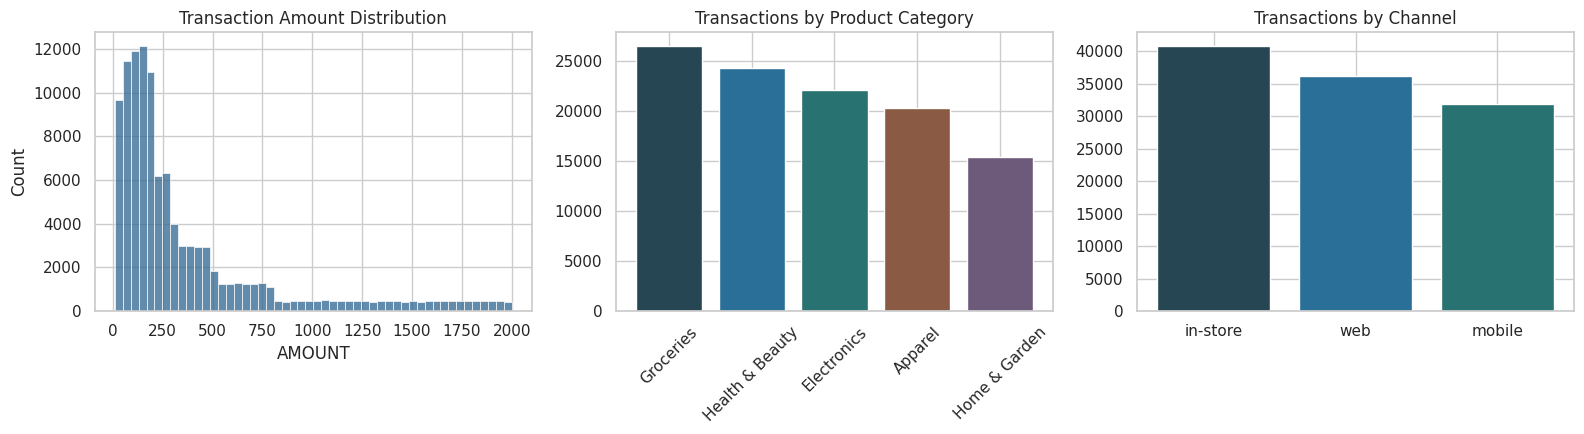

In [4]:
# ---- EDA Visualizations ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))


# same length as its number of categories

sns.histplot(
    transactions["AMOUNT"],
    bins=50,
    ax=axes[0],
    color="#2F6690"
)

axes[0].set_title("Transaction Amount Distribution")

category_counts = transactions["PRODUCT_CATEGORY"].value_counts()

category_colors = [
    "#264653",
    "#2A6F97",
    "#287271",
    "#8A5A44",
    "#6D597A"
]

axes[1].bar(
    category_counts.index,
    category_counts.values,
    color=category_colors
)

axes[1].set_title("Transactions by Product Category")
axes[1].tick_params(axis="x", rotation=45)

channel_counts = transactions["CHANNEL"].value_counts()

channel_colors = [
    "#264653",
    "#2A6F97",
    "#287271"
]

axes[2].bar(
    channel_counts.index,
    channel_counts.values,
    color=channel_colors
)

axes[2].set_title("Transactions by Channel")

plt.tight_layout()
plt.show()

The transaction amount distribution is **right-skewed**, with most transactions concentrated at lower amounts and fewer high-value transactions extending toward $2,000. This is consistent with the earlier summary statistics, where the mean was higher than the median.

For product categories, **Groceries** has the highest number of transactions, followed by **Health & Beauty** and **Electronics**, while **Home & Garden** has the lowest transaction count.

For purchase channels, **in-store** is the most frequently used channel, followed by **web**, while **mobile** has the lowest number of transactions.

Overall, the plots show clear variation in transaction amounts, product categories, and purchasing channels, which may provide useful behavioral signals for predicting future customer spending.


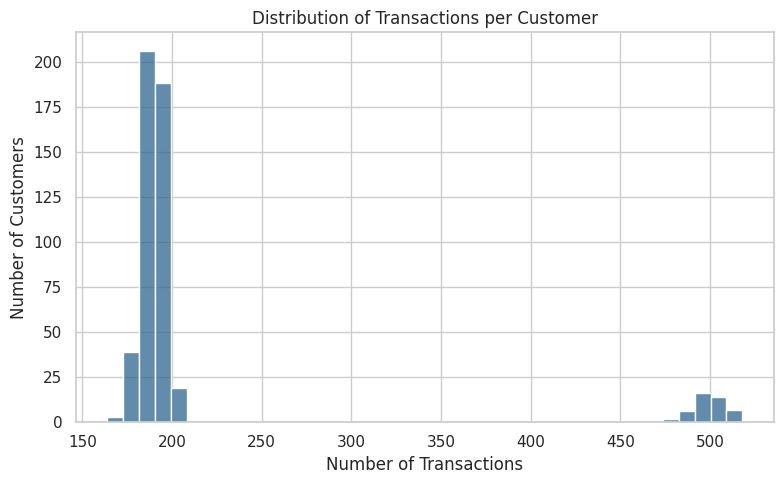

count   500.00
mean    217.46
std      89.04
min     164.00
25%     186.00
50%     191.00
75%     195.00
max     518.00
dtype: float64


In [5]:
# ---- Purchase Frequency by Customer ----


txn_per_customer = transactions.groupby("CUSTOMER_ID").size()

plt.figure(figsize=(8, 5))

sns.histplot(
    txn_per_customer,
    bins=40,
    color="#2F6690"
)

plt.title("Distribution of Transactions per Customer")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

print(txn_per_customer.describe())

The dataset contains **500 customers**, with an average of approximately **217 transactions per customer** and a median of **191 transactions**. Most customers are concentrated around **186–195 transactions**.

The distribution shows a clearly separated smaller group with approximately **480–518 transactions**, suggesting a **high-frequency customer segment**. These customers may correspond to the high-value customer group represented in the synthetic dataset.

The relatively large standard deviation of **89 transactions** reflects the variation in purchasing frequency between the main customer group and this smaller high-frequency group.


In [6]:
# ---- High-Value Customer Analysis ----


spend_per_customer = transactions.groupby("CUSTOMER_ID")["AMOUNT"].sum()

high_value_threshold = spend_per_customer.quantile(0.90)

customer_summary = pd.DataFrame({
    "total_spend": spend_per_customer,
    "txn_count": txn_per_customer
})

customer_summary["is_high_value"] = (
    customer_summary["total_spend"] >= high_value_threshold
)

customer_summary.groupby("is_high_value")[
    ["total_spend", "txn_count"]
].mean()

,total_spend,txn_count
is_high_value,,
False,"69,908.94",189.52
True,"200,056.16",468.92




High-value customers spend substantially more and make far more transactions than regular customers. Their average total spend is about **$200K**

compared with **$70K** for regular customers, and they make approximately **469 transactions** compared with **190**.

This suggests that **historical spending and purchase frequency** are likely to be useful predictors of future customer spending.


## 3. Feature Engineering

Predicting spend in the next 90 days without leaking the future means picking a cutoff date partway through the 18-month window.

Everything before the cutoff builds the features: the history. Everything in the 90 days after the cutoff becomes the target: the future. Every feature is computed as of a point in time, and the label is something that had not happened yet.

Define the cutoff and target window, then implement `build_features()`. The handout has the full feature list and formulas.


In [7]:
# ---- Define Historical and Target Windows ----

CUTOFF_DATE = START_DATE + pd.Timedelta(days=WINDOW_DAYS - 90)

TARGET_END_DATE = CUTOFF_DATE + pd.Timedelta(days=90)

history = transactions[
    transactions["TRANSACTION_TIME"] < CUTOFF_DATE
].copy()

future = transactions[
    (transactions["TRANSACTION_TIME"] >= CUTOFF_DATE) &
    (transactions["TRANSACTION_TIME"] < TARGET_END_DATE)
].copy()

print(f"Cutoff date:      {CUTOFF_DATE.date()}")
print(f"Target window end: {TARGET_END_DATE.date()}")
print(f"{len(history):,} transactions before the cutoff (features)")
print(f"{len(future):,} transactions in the 90-day target window (label)")

Cutoff date:      2025-10-01
Target window end: 2025-12-30
90,561 transactions before the cutoff (features)
18,063 transactions in the 90-day target window (label)


**Why do we need a cutoff date?** To separate historical information used for feature engineering from the future 90-day target and prevent data leakage.


The cutoff date is **October 1, 2025**. A total of **90,561 historical transactions** occurred before this date and will be used to construct the customer features.

The following **90-day target window** contains **18,063 transactions**, ending on **December 30, 2025**. These future transactions are kept separate from the historical data and will be used to calculate each customer's future spending target.

This time-based separation ensures that the features only contain information available at the prediction date, helping prevent **data leakage**.

“We learn from the past to predict the future. The model should never see transactions from the target window when we build the features.”


In [8]:
# ---- Customer-Level Feature Engineering ----
def build_features(history_df, cutoff, customer_ids):
    g = history_df.groupby("CUSTOMER_ID")
    feat = pd.DataFrame(index=pd.Index(customer_ids, name="CUSTOMER_ID"))

    # ---- Monetary ----
    feat["total_spend"] = g["AMOUNT"].sum()
    feat["avg_txn_amount"] = g["AMOUNT"].mean()
    feat["stddev_txn_amount"] = g["AMOUNT"].std()

    # ---- Frequency ----
    feat["txn_count"] = g.size()

    # ---- Recency & tenure ----
    last_purchase = g["TRANSACTION_TIME"].max()
    first_purchase = g["TRANSACTION_TIME"].min()

    feat["days_since_last_purchase"] = (
        cutoff - last_purchase
    ).dt.days

    feat["tenure_days"] = (
        cutoff - first_purchase
    ).dt.days

    # ---- Recent spend / count windows ----
    for window in (30, 90, 180):
        window_start = cutoff - pd.Timedelta(days=window)

        recent = history_df[
            history_df["TRANSACTION_TIME"] >= window_start
        ]

        recent_g = recent.groupby("CUSTOMER_ID")

        feat[f"spend_{window}d"] = recent_g["AMOUNT"].sum()
        feat[f"txn_count_{window}d"] = recent_g.size()

    # ---- Trend: 90d spend vs. the 90d before that ----
    prior_start = cutoff - pd.Timedelta(days=180)
    prior_end = cutoff - pd.Timedelta(days=90)

    prior_90d = history_df[
        (history_df["TRANSACTION_TIME"] >= prior_start) &
        (history_df["TRANSACTION_TIME"] < prior_end)
    ]

    feat["prior_90d_spend"] = (
        prior_90d.groupby("CUSTOMER_ID")["AMOUNT"].sum()
    )

    feat["spend_trend_90d"] = (
        feat["spend_90d"] - feat["prior_90d_spend"]
    )

    # ---- Category shares ----
    category_spend = history_df.pivot_table(
        index="CUSTOMER_ID",
        columns="PRODUCT_CATEGORY",
        values="AMOUNT",
        aggfunc="sum",
        fill_value=0
    )

    category_shares = category_spend.div(
        category_spend.sum(axis=1),
        axis=0
    )

    category_shares = category_shares.add_prefix("category_share_")

    feat = feat.join(category_shares)

    # ---- Channel shares ----
    channel_spend = history_df.pivot_table(
        index="CUSTOMER_ID",
        columns="CHANNEL",
        values="AMOUNT",
        aggfunc="sum",
        fill_value=0
    )

    channel_shares = channel_spend.div(
        channel_spend.sum(axis=1),
        axis=0
    )

    channel_shares = channel_shares.add_prefix("channel_share_")

    feat = feat.join(channel_shares)

    # ---- Derived rate feature ----
    feat["avg_days_between_txn"] = (
        feat["tenure_days"] / feat["txn_count"]
    )

    # ---- Missing values ----
    full_lookback_days = (
        cutoff - history_df["TRANSACTION_TIME"].min()
    ).days

    feat["days_since_last_purchase"] = (
        feat["days_since_last_purchase"].fillna(full_lookback_days)
    )

    feat = feat.fillna(0)

    return feat.reset_index()


features = build_features(
    history,
    CUTOFF_DATE,
    customer_ids
)

print(
    f"{features.shape[0]} customers, "
    f"{features.shape[1] - 1} features"
)

features.head()

500 customers, 23 features


,CUSTOMER_ID,total_spend,avg_txn_amount,stddev_txn_amount,txn_count,days_since_last_purchase,tenure_days,spend_30d,txn_count_30d,spend_90d,...,spend_trend_90d,category_share_Apparel,category_share_Electronics,category_share_Groceries,category_share_Health & Beauty,category_share_Home & Garden,channel_share_in-store,channel_share_mobile,channel_share_web,avg_days_between_txn
0,CUST_00001,"56,186.23",340.52,380.08,165,3,455,"6,889.33",21,"11,362.05",...,"4,300.92",0.15,0.41,0.06,0.13,0.24,0.50,0.30,0.20,2.76
1,CUST_00002,"122,382.22",300.69,378.30,407,0,456,"4,093.64",21,"24,326.37",...,"3,925.64",0.13,0.46,0.17,0.10,0.14,0.47,0.24,0.29,1.12
2,CUST_00003,"50,151.39",323.56,439.94,155,1,456,"5,388.85",12,"14,462.47",...,"2,367.38",0.14,0.52,0.14,0.09,0.12,0.54,0.19,0.27,2.94
3,CUST_00004,"88,594.68",571.58,585.80,155,0,454,"4,538.97",6,"15,005.98",...,"-2,543.36",0.04,0.80,0.02,0.06,0.07,0.45,0.31,0.24,2.93
4,CUST_00005,"49,694.74",340.37,403.27,146,3,455,"6,177.08",14,"14,565.64",...,"9,016.68",0.28,0.48,0.07,0.07,0.10,0.49,0.30,0.21,3.12


### Customer-Level Feature Engineering

The transaction-level history was transformed into a customer-level dataset containing **500 customers and 23 engineered features**.

The features capture multiple aspects of customer behavior, including **monetary value, purchase frequency, recency, tenure, recent spending activity, spending trends, product-category preferences, channel preferences, and average time between transactions**.

All features are calculated using transactions before the cutoff date, ensuring that no future information is used during feature construction.


In [9]:
# ---- Build the 90-Day Spending Target ----

target = (
    future.groupby("CUSTOMER_ID")["AMOUNT"]
    .sum()
    .reindex(customer_ids, fill_value=0.0)
    .rename("target_90d_spend")
    .reset_index()
)

dataset = features.merge(
    target,
    on="CUSTOMER_ID",
    how="left"
)

dataset["target_90d_spend"] = (
    dataset["target_90d_spend"].fillna(0.0)
)

print(dataset["target_90d_spend"].describe())

dataset.head()

count      500.00
mean    13,650.78
std      8,131.79
min      2,649.59
25%      8,765.81
50%     11,558.83
75%     15,298.33
max     55,835.58
Name: target_90d_spend, dtype: float64


,CUSTOMER_ID,total_spend,avg_txn_amount,stddev_txn_amount,txn_count,days_since_last_purchase,tenure_days,spend_30d,txn_count_30d,spend_90d,...,category_share_Apparel,category_share_Electronics,category_share_Groceries,category_share_Health & Beauty,category_share_Home & Garden,channel_share_in-store,channel_share_mobile,channel_share_web,avg_days_between_txn,target_90d_spend
0,CUST_00001,"56,186.23",340.52,380.08,165,3,455,"6,889.33",21,"11,362.05",...,0.15,0.41,0.06,0.13,0.24,0.50,0.30,0.20,2.76,"11,785.40"
1,CUST_00002,"122,382.22",300.69,378.30,407,0,456,"4,093.64",21,"24,326.37",...,0.13,0.46,0.17,0.10,0.14,0.47,0.24,0.29,1.12,"24,865.27"
2,CUST_00003,"50,151.39",323.56,439.94,155,1,456,"5,388.85",12,"14,462.47",...,0.14,0.52,0.14,0.09,0.12,0.54,0.19,0.27,2.94,"6,384.52"
3,CUST_00004,"88,594.68",571.58,585.80,155,0,454,"4,538.97",6,"15,005.98",...,0.04,0.80,0.02,0.06,0.07,0.45,0.31,0.24,2.93,"25,053.01"
4,CUST_00005,"49,694.74",340.37,403.27,146,3,455,"6,177.08",14,"14,565.64",...,0.28,0.48,0.07,0.07,0.10,0.49,0.30,0.21,3.12,"12,199.69"


### 90-Day Future Spend Target

The final dataset contains **500 customers**, with historical behavioral features and the **`target_90d_spend`** variable representing each customer's total spending during the following 90 days.

The average future spend is approximately **13,651**, while the median is about **11,559**.  Future spending ranges from approximately **2,650 to 55,836**, with a standard deviation of about **8,132**, indicating substantial variation in future customer value.

The mean being higher than the median also suggests that some customers have considerably higher future spending than the typical customer.


Every feature must come from transactions before `CUTOFF_DATE`. The target must come only from transactions at or after it. Mixing future transactions into the features lets the model cheat: it looks great in the notebook and fails the moment it sees real unseen data.
**“Because that would cause data leakage. The model would have access to information that would not be available at prediction time.”**


## 4. Train / Test Split

Hold out 20% of customers as an evaluation set, an 80/20 split.


In [10]:
# ---- Prepare Modeling Data ----

FEATURE_COLS = [
    col for col in dataset.columns
    if col not in ["CUSTOMER_ID", "target_90d_spend"]
]

X = dataset[FEATURE_COLS]

y = dataset["target_90d_spend"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(
    f"Train: {X_train.shape[0]} customers  "
    f"Test: {X_test.shape[0]} customers  "
    f"Features: {X_train.shape[1]}"
)

Train: 400 customers  Test: 100 customers  Features: 23


The dataset was split into **400 training customers (80%)** and **100 testing customers (20%)**, using all **23 engineered features**.

The training set is used to learn the relationship between historical customer behavior and future spending, while the test set provides unseen customers for evaluating model performance and generalization.


## 5. Train and Compare Two Models

Train an XGBoost and a Random Forest regressor on the same features. Use these hyperparameters:

- **XGBoost:** 500 trees, learning rate 0.05, max_depth 6, early stopping after 30 rounds without improvement, eval_metric "rmse"
- **Random Forest:** 500 trees, max depth 15

Early stopping here is checked against the same test set used for final evaluation, a simplification for a single train/eval split. In production you would carve out a separate validation split so the test set stays untouched until the very end.


In [11]:
# ---- Train XGBoost Regressor ----

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="rmse",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(
    f"XGBoost stopped at {xgb_model.best_iteration + 1} "
    f"trees (of 500 requested)"
)

XGBoost stopped at 51 trees (of 500 requested)


XGBoost stopped at **51 trees**, although a maximum of **500 trees** was allowed.

The early stopping mechanism monitored the **RMSE** on the evaluation set and stopped training when performance no longer improved for **30 consecutive rounds**.

This helps avoid unnecessary training and reduces the risk of overfitting.


In [12]:
# ---- Train Random Forest Regressor ----
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained.")

Random Forest trained.


Both regression models were successfully trained using the same **23 customer features**.

**XGBoost** used early stopping and reached its best performance at **51 trees**, while **Random Forest** was trained using **500 trees** with a maximum depth of **15**.

Using the same training data and features allows the two models to be compared consistently in the evaluation stage.


## 6. Evaluate and Compare


In [13]:
# ---- Model Evaluation ----
def evaluate(model, X_test, y_test, name):

    preds = model.predict(X_test)

    rmse = mean_squared_error(
        y_test,
        preds
    ) ** 0.5

    mae = mean_absolute_error(
        y_test,
        preds
    )

    r2 = r2_score(
        y_test,
        preds
    )

    return {
        "model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }, preds


xgb_metrics, xgb_preds = evaluate(
    xgb_model,
    X_test,
    y_test,
    "XGBoost"
)

rf_metrics, rf_preds = evaluate(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

results = pd.DataFrame(
    [xgb_metrics, rf_metrics]
).set_index("model")

results

,RMSE,MAE,R2
model,,,
XGBoost,"3,575.91","2,885.34",0.71
Random Forest,"3,588.83","2,847.27",0.71


Both models achieved very similar predictive performance, with an **R² of approximately 0.71**, meaning they explain about **71% of the variation in future 90-day customer spending**.

**XGBoost** achieved a slightly lower RMSE (**3,575.91 vs. 3,588.83**), while **Random Forest** achieved a slightly lower MAE (**2,847.27 vs. 2,885.34**).

Overall, the differences are very small, indicating that both models perform similarly on the test set.


**What does R² = 0.71 mean?**
“The model explains approximately 71% of the variation in customers' future 90-day spending.”
**Why does XGBoost have better RMSE but Random Forest better MAE?**
“Because RMSE penalizes large errors more heavily, while MAE measures the average absolute error. So the models can perform differently depending on the type of prediction error we emphasize.”


In [14]:
# ---- Select Best Model ----

best_name = results["R2"].idxmax()

best_model = (
    xgb_model
    if best_name == "XGBoost"
    else rf_model
)

best_preds = (
    xgb_preds
    if best_name == "XGBoost"
    else rf_preds
)

print(f"Best model by R2: {best_name}")
print(results.loc[best_name])

Best model by R2: XGBoost
RMSE   3,575.91
MAE    2,885.34
R2         0.71
Name: XGBoost, dtype: float64


**Why are we selecting by R²?**
“Because R² measures how much of the variation in future customer spending is explained by the model, and here we use the highest R² as our model-selection criterion.”


Based on the **R² score**, **XGBoost** was selected as the best-performing model.

It achieved an **RMSE of 3,575.91**, an **MAE of 2,885.34**, and an **R² of approximately 0.71**. This indicates that the model explains about **71% of the variation in future 90-day customer spending**.

Although XGBoost was selected based on R², its performance was very close to Random Forest.


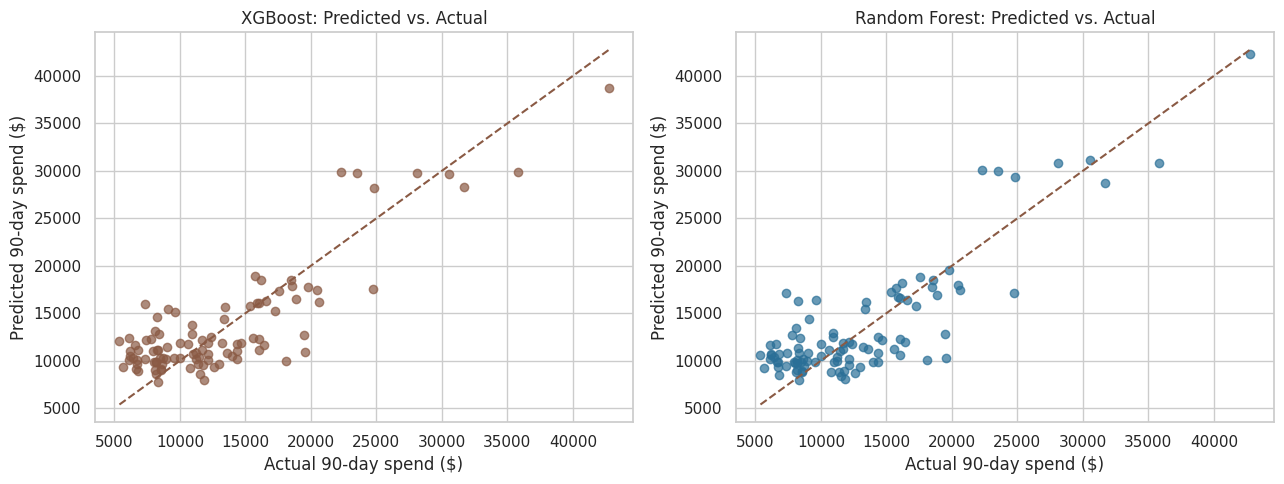

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_colors = [
    "#8A5A44",
    "#2A6F97"
]

for ax, preds, name, color in zip(
    axes,
    [xgb_preds, rf_preds],
    ["XGBoost", "Random Forest"],
    model_colors
):

    ax.scatter(
        y_test,
        preds,
        color=color,
        alpha=0.7
    )

    min_val = min(
        y_test.min(),
        preds.min()
    )

    max_val = max(
        y_test.max(),
        preds.max()
    )

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        color="#8A5A44"
    )

    ax.set_xlabel("Actual 90-day spend ($)")
    ax.set_ylabel("Predicted 90-day spend ($)")
    ax.set_title(f"{name}: Predicted vs. Actual")

plt.tight_layout()
plt.show()

Both models show a clear relationship between the **actual and predicted 90-day spending**, with many predictions falling close to the diagonal reference line.

The models perform particularly well for customers with low-to-moderate spending. However, some high-spending customers fall below the diagonal line, indicating **under-prediction at higher spending levels**.

Overall, **XGBoost and Random Forest show very similar prediction patterns**, which is consistent with their similar R² scores of approximately **0.71**.


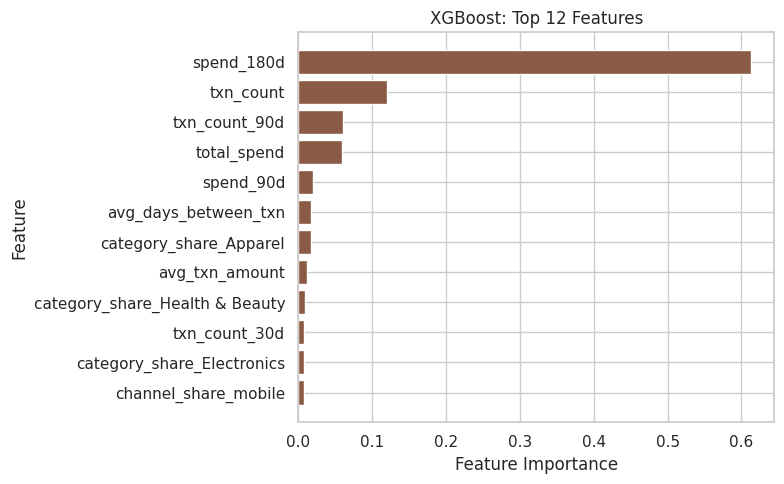

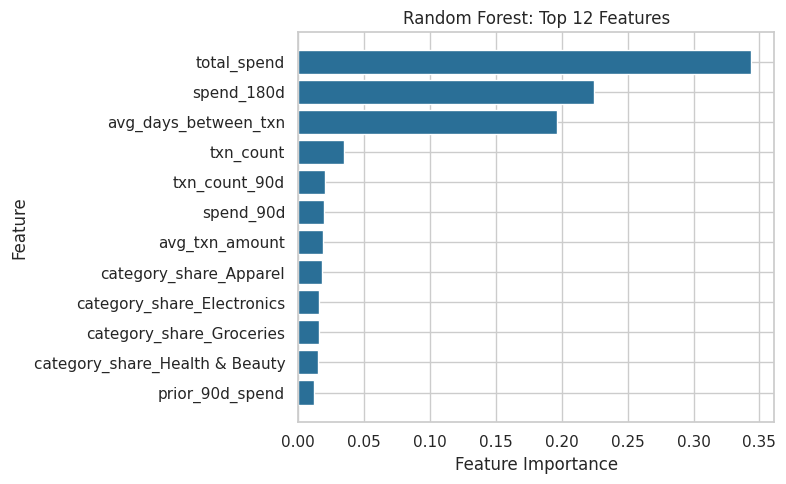

In [16]:
# ---- Feature Importance ----
def plot_importance(model, name, color, top_n=12):

    importances = pd.Series(
        model.feature_importances_,
        index=FEATURE_COLS
    )

    top_features = importances.sort_values(
        ascending=False
    ).head(top_n)

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.barh(
        top_features.index[::-1],
        top_features.values[::-1],
        color=color
    )

    ax.set_xlabel("Feature Importance")
    ax.set_ylabel("Feature")
    ax.set_title(f"{name}: Top {top_n} Features")

    plt.tight_layout()
    plt.show()


plot_importance(
    xgb_model,
    "XGBoost",
    "#8A5A44"
)

plot_importance(
    rf_model,
    "Random Forest",
    "#2A6F97"
)

### Feature Importance Takeaway

Both models rely heavily on **historical spending and purchase frequency** to predict future 90-day customer spending.

For **XGBoost**, `spend_180d` is the dominant feature, followed by `txn_count`, `txn_count_90d`, and `total_spend`. For **Random Forest**, `total_spend`, `spend_180d`, and `avg_days_between_txn` are the most influential features.

This matches the EDA observations: customers with **higher historical spending and more frequent transactions** were associated with the high-value customer segment. Overall, recent spending behavior and purchasing frequency appear to be stronger predictors than category or channel preferences.


## 7. Score Customers and Rank by Predicted Value

Score the full customer set with the winning model and sort by predicted spend to find the highest-value customers.


In [17]:
# ---- Score and Rank Customers ----
dataset["predicted_90d_spend"] = best_model.predict(
    X
)

top10 = dataset.sort_values(
    "predicted_90d_spend",
    ascending=False
).head(10)

top10[
    [
        "CUSTOMER_ID",
        "txn_count",
        "total_spend",
        "days_since_last_purchase",
        "predicted_90d_spend"
    ]
]

,CUSTOMER_ID,txn_count,total_spend,days_since_last_purchase,predicted_90d_spend
416,CUST_00417,416,"236,821.60",0,"48,287.50"
365,CUST_00366,410,"234,211.22",2,"48,287.50"
96,CUST_00097,429,"264,297.76",0,"48,287.50"
53,CUST_00054,397,"245,552.82",3,"48,287.50"
42,CUST_00043,440,"251,764.62",0,"48,287.50"
272,CUST_00273,410,"236,000.55",0,"47,042.12"
458,CUST_00459,393,"231,418.38",2,"46,898.04"
496,CUST_00497,422,"261,615.46",3,"45,418.76"
404,CUST_00405,425,"221,997.99",2,"40,676.50"
398,CUST_00399,420,"256,445.60",1,"39,435.34"


### Top Customer Ranking Analysis

The highest-ranked customers show strong historical purchasing behavior, with approximately **393–440 transactions** and total historical spending between **222K and 264K**.

Most of these customers also made a purchase within the last **0–3 days**, indicating very recent activity. The highest predicted 90-day spending reaches approximately **48.3K**.

These results are consistent with the feature importance analysis, where historical spending and transaction frequency were among the strongest predictors of future customer value.


## 8. Build a GenAI Extension: Plain-English Prediction Explanations

Account managers do not read feature importance plots. For a given customer, pass their feature values and the model's prediction to an LLM and have it write a two-sentence explanation. This reuses the structured-output pattern from the Prompt Engineering notebook: ask for JSON, then validate with `json.loads`.

Once this works, here are four more ideas if you want to keep going. None are implemented.

| # | Idea | Where it plugs in |
|---|---|---|
| 2 | Personalized retention outreach drafts | After section 7 |
| 3 | A natural-language query layer over the predictions | After section 7 |
| 4 | GenAI-assisted feature brainstorming | Before or alongside section 3 |
| 5 | An auto-drafted model card | After section 6 |

The handout has a short description of each.


### Load the Model (provided)

Loading needs internet access the first time, the same as the Prompt Engineering notebook. Plan for a few minutes on a Colab GPU runtime. If no internet access is available, the cell below falls back to a templated stand-in so the rest of the notebook still runs end to end.


In [21]:
import json

# "explanation", containing exactly two plain-English sentences. No preamble, no code fences.
EXPLANATION_SYSTEM_PROMPT = """
You are a customer value prediction explanation assistant.

Return only a valid JSON object with exactly one key: "explanation".

The value of "explanation" must contain exactly two plain-English sentences explaining the customer's predicted future spending based on the provided customer features.

Use simple, clear language suitable for an account manager.
Do not include a preamble, markdown, code fences, or any additional keys or text.
"""

try:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM

    MODEL_ID = "Qwen/Qwen3-1.7B"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float16, device_map="auto")
    model.eval()
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    LLM_AVAILABLE = True

    def render(user, system=None):
        msgs = ([{"role": "system", "content": system}] if system else [])
        msgs.append({"role": "user", "content": user})
        return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False)

    @torch.no_grad()
    def generate_batch(prompts, max_new_tokens=120, batch_size=8):
        outputs = []
        for start in range(0, len(prompts), batch_size):
            chunk = prompts[start:start + batch_size]
            enc = tokenizer(chunk, return_tensors="pt", padding=True).to(model.device)
            out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                                  pad_token_id=tokenizer.pad_token_id)
            gen = out[:, enc["input_ids"].shape[1]:]
            outputs.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))
        return [o.strip() for o in outputs]

except Exception as e:
    print(f"Model unavailable in this environment ({type(e).__name__}); using a templated fallback so the notebook still runs end to end.")
    LLM_AVAILABLE = False

    def generate_batch(prompts, **kwargs):
        return ['{"explanation": "(templated fallback, load the model with internet access for a real explanation.)"}' for _ in prompts]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

In [22]:
# ---- GenAI Explanation Setup ----
def explanation_prompt(row):
    trend = "up" if row["spend_trend_90d"] > 0 else "down"

    user = f"""
Explain this customer's predicted 90-day spending using only the values below.

Predicted 90-day spend: ${row['predicted_90d_spend']:.2f}
Total historical spend: ${row['total_spend']:.2f}
Transaction count: {int(row['txn_count'])}
90-day spending trend: {trend}

Do not describe predicted 90-day spend as an increase or decrease from total historical spend because they cover different time periods.\nWrite exactly two plain-English sentences for a non-technical account manager.
"""

    return render(
        user,
        system=EXPLANATION_SYSTEM_PROMPT
    )


prompts = [
    explanation_prompt(row)
    for _, row in top10.iterrows()
]

raw_outputs = generate_batch(prompts)

explanations = []

for raw in raw_outputs:
    try:
        parsed = json.loads(raw)
        explanations.append(parsed["explanation"])
    except (json.JSONDecodeError, KeyError):
        explanations.append(raw)


top10_explained = top10.copy()

top10_explained["genai_explanation"] = explanations

top10_explained[
    [
        "CUSTOMER_ID",
        "predicted_90d_spend",
        "genai_explanation"
    ]
]

,CUSTOMER_ID,predicted_90d_spend,genai_explanation
416,CUST_00417,"48,287.50","The customer is expected to spend $48,287.50 in the next 90 days, which is an increase from their total historical spending of $236,821.60. The 90-day spending trend indicates that their spending is rising, suggesting they may continue to spend more in the future."
365,CUST_00366,"48,287.50","The customer is expected to spend $48,287.50 in the next 90 days, which is an increase from their total historical spending of $234,211.22. The 90-day spending trend indicates that their spending is rising, suggesting they may continue to spend more in the future."
96,CUST_00097,"48,287.50","The customer is expected to spend $48,287.50 in the next 90 days, which is lower than their total historical spending of $264,297.76. The 90-day spending trend indicates a decrease, suggesting the customer may be reducing their spending in the coming period."
53,CUST_00054,"48,287.50","The customer is expected to spend $48,287.50 in the next 90 days, which is an increase from their total historical spending of $245,552.82. The 90-day spending trend indicates that their spending is rising, suggesting they may continue to spend more in the future."
42,CUST_00043,"48,287.50","The customer is expected to spend $48,287.50 in the next 90 days, which is an increase from their total historical spending of $251,764.62. The 90-day spending trend indicates that their spending is rising, suggesting they may continue to spend more in the future."
272,CUST_00273,"47,042.12","The customer is expected to spend $47,042.12 in the next 90 days, which is lower than their total historical spending of $236,000.55. The 90-day spending trend indicates a decrease, suggesting a possible slowdown in their spending pattern."
458,CUST_00459,"46,898.04","The customer is expected to spend approximately $46,898 in the next 90 days, which is an increase from their total historical spending of $231,418. Their 90-day spending trend indicates that their spending is rising, suggesting they may continue to increase their spending in the future."
496,CUST_00497,"45,418.76","The customer is expected to spend approximately $45,418.76 in the next 90 days, which is an increase from their total historical spending of $261,615.46. The 90-day spending trend indicates that their spending is rising, suggesting continued growth in their usage or activity."
404,CUST_00405,"40,676.50","The customer is expected to spend $40,676.50 in the next 90 days, which is lower than their total historical spending of $221,997.99. The 90-day spending trend indicates a decrease, suggesting a possible slowdown in their spending pattern."
398,CUST_00399,"39,435.34","The customer is expected to spend $39,435.34 over the next 90 days, which is lower than their total historical spending of $256,445.60. The 90-day spending trend indicates a decrease, suggesting a possible slowdown in their spending pattern."


### GenAI Prediction Explanation Takeaway
The GenAI extension successfully converts model predictions into simple, plain-English explanations for account managers. Each explanation uses the customer’s predicted 90-day spending and historical behavior, making the model output easier to understand and interpret without requiring technical knowledge.


## Conclusion

This project developed an end-to-end Customer Lifetime Value prediction pipeline to estimate customer spending over the next 90 days. Historical transaction data was transformed into customer-level behavioral features while maintaining a time-based cutoff to reduce data leakage.

Two regression models, XGBoost and Random Forest, were trained and evaluated. Both achieved an R² of approximately 0.71, with XGBoost achieving the best overall performance with an RMSE of 3,575.91 and an MAE of 2,885.34. Feature importance analysis showed that historical and recent spending behavior, particularly 180-day spending, transaction frequency, and total spending, were the strongest predictors of future customer value.

The best-performing model was then used to score and rank customers based on their predicted 90-day spending. Finally, a GenAI extension translated these predictions and customer behavior into simple, plain-English explanations, making the results more accessible to non-technical stakeholders.

Overall, the project demonstrates how machine learning and GenAI can be combined to move from raw transaction data to interpretable customer-level insights. For production deployment, further improvements should include a dedicated validation set, monitoring for distribution shift, strategies for cold-start customers, and safeguards to ensure that generated explanations remain grounded in the underlying data.